# From Q-tables to deep Q-networks

**Value-based reinforcement learning, from just data-driven to NN**

This is aimed as an introduction to RL relying on **value-based** methods.
Using Q-learning, we do not parametrise our policy, but the value of every *action* in
every *state* is learnt, and the policy is whatever is greedy with respect to the space explored.

We do this moving from an initial 25x4
**table** that we can check against the exact answer, and
then we generalise with a **network** (**DQN**) that has to represent the same function without
creating a table.

| Part | Topic |
|---|---|
| 0 | The environment (recap) and the random baseline |
| 1 | Exact `Q*` by value iteration |
| 2 | Tabular Q-learning |
| 3 | What the table learned |
| 4 | Scaling aspects |
| 5 | DQN: Q-learning with a network |
| 6 | How much do replay and the target network matter? |

**Prerequisites:** notebook from day 2 (Gymnasium environments, episodes, returns).


In [1]:
try:
    import gymnasium as gym
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gymnasium"], check=True)
    import gymnasium as gym

import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from gymnasium import spaces
from gymnasium.wrappers import TimeLimit
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

torch.manual_seed(0)
rng = np.random.default_rng(0)

# One colour is one identity.
C_RANDOM = "#8a8983"   # the random-policy baseline (the "no model" grey)
C_TABLE  = "#8a5cf0"   # tabular Q-learning (the 25x4 table)
C_DQN    = "#1baf7a"   # the trained network (the same green as PPO in notebook 3)
C_TRUTH  = "#0b0b0b"   # exact answers, start/goal markers
C_WALL   = "#3a3a38"
C_NOTGT  = "#c2703d"   # DQN, target network removed
C_NOBUF  = "#d1495b"   # DQN, replay buffer removed

plt.rcParams.update({
    "figure.figsize": (7, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.edgecolor": "#c9c8c4", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "lines.linewidth": 2.0, "font.size": 11, "legend.frameon": False,
})

GAMMA = 0.99          # one discount factor, used by every method in this notebook
print("gymnasium", gym.__version__, "| torch", torch.__version__)

gymnasium 0.29.1 | torch 2.4.1


---
# 0. The environment, and the floor to beat

## 0.1 The same grid world

A 5x5 grid, the agent starts top-left, the goal is bottom-right, and a short
wall down the middle blocks the direct route. Each step costs `-1`, closing the distance to the goal earns `+0.5`, and arriving pays `+10`. This is the same environment used in the day 2 notebook.

In [2]:
class GridWorldEnv(gym.Env):
    metadata = {"render_modes": ["ansi"]}

    def __init__(self, size=5, walls=((1, 2), (2, 2), (3, 2)), start=(0, 0), goal=(4, 4)):
        super().__init__()
        self.size = size
        self.walls = set(walls)
        self.start = start
        self.goal = goal
        # The agent cannot measure distances, it has
        # to learn the grid's geometry from returns alone.
        self.observation_space = spaces.Box(0.0, 1.0, shape=(size * size,), dtype=np.float32)
        self.action_space = spaces.Discrete(4)   # 0=up 1=down 2=left 3=right
        self._deltas = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}

    def _dist(self, pos):
        return abs(pos[0] - self.goal[0]) + abs(pos[1] - self.goal[1])

    def _obs(self):
        v = np.zeros(self.size * self.size, dtype=np.float32)
        r, c = self.agent_pos
        v[r * self.size + c] = 1.0
        return v

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = self.start
        return self._obs(), {}

    def step(self, action):
        dr, dc = self._deltas[int(action)]
        r, c = self.agent_pos
        nr, nc = r + dr, c + dc
        old_dist = self._dist(self.agent_pos)
        in_bounds = 0 <= nr < self.size and 0 <= nc < self.size
        if in_bounds and (nr, nc) not in self.walls:
            self.agent_pos = (nr, nc)          # otherwise: bump the wall/edge, stay put
        new_dist = self._dist(self.agent_pos)

        terminated = self.agent_pos == self.goal
        reward = -1.0 + 0.5 * (old_dist - new_dist) + (10.0 if terminated else 0.0)
        return self._obs(), reward, terminated, False, {}

    def render(self):
        rows = []
        for r in range(self.size):
            row = []
            for c in range(self.size):
                if (r, c) == self.agent_pos:
                    row.append("A")
                elif (r, c) == self.goal:
                    row.append("G")
                elif (r, c) in self.walls:
                    row.append("#")
                else:
                    row.append(".")
            rows.append(" ".join(row))
        return "\n".join(rows)


MAX_STEPS = 50                       # the step budget for one episode

def make_env():
    return TimeLimit(GridWorldEnv(), max_episode_steps=MAX_STEPS)


BASE = GridWorldEnv()                # a plain, unwrapped copy for geometry lookups
N_STATES = BASE.size * BASE.size
N_ACTIONS = BASE.action_space.n
FREE_CELLS = [(r, c) for r in range(BASE.size) for c in range(BASE.size) if (r, c) not in BASE.walls]

def cell_index(cell):
    return cell[0] * BASE.size + cell[1]

def state_of(obs):
    # Our observations are one-hot, so "which state am I in" is just the hot index.
    return int(np.argmax(obs))

env0 = make_env()
env0.reset()
print(env0.unwrapped.render())
print(f"\n{N_STATES} states x {N_ACTIONS} actions = {N_STATES * N_ACTIONS} numbers to learn")

A . . . .
. . # . .
. . # . .
. . # . .
. . . . G

25 states x 4 actions = 100 numbers to learn


## 0.2 The random-policy floor

We net to set a baseline first: a policy that ignores the observation and picks
uniformly at random. This was also used as a baseline on day 2.

In [3]:
def run_episode(policy, env=None, max_steps=MAX_STEPS):
    # Runs one episode under `policy(obs) -> action`. Returns (path, return, length).
    env = env or make_env()
    obs, _ = env.reset()
    path = [env.unwrapped.agent_pos]
    total, length = 0.0, 0
    terminated = truncated = False
    while not (terminated or truncated):
        obs, reward, terminated, truncated, _ = env.step(policy(obs))
        path.append(env.unwrapped.agent_pos)
        total += reward
        length += 1
    return path, total, length


def random_policy(obs):
    return int(rng.integers(N_ACTIONS))


episodes = [run_episode(random_policy) for _ in range(1000)]
random_returns = np.array([ret for _, ret, _ in episodes])
random_lengths = np.array([length for _, _, length in episodes])
random_success = (random_lengths < MAX_STEPS).mean()
random_path, random_return, random_length = episodes[0]

print(f"random policy over 1000 episodes:")
print(f"  mean return   {random_returns.mean():7.2f}")
print(f"  success rate  {random_success:7.1%}")

OPTIMAL_STEPS = 8                                        # shortest route around the wall
OPTIMAL_RETURN = OPTIMAL_STEPS * (-1.0 + 0.5) + 10.0     # the undiscounted ceiling
print(f"\noptimal (undiscounted) return: {OPTIMAL_RETURN:.2f} in {OPTIMAL_STEPS} steps")

random policy over 1000 episodes:
  mean return    -41.62
  success rate    22.4%

optimal (undiscounted) return: 6.00 in 8 steps


---
# 1. The exact answer

Value-based RL is built on the **action-value function**

$$Q^\pi(s, a) = \mathbb{E}\left[\, r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \dots \;\middle|\; s_t = s,\ a_t = a,\ \text{then follow } \pi \right]$$

"if I am in state `s`, take action `a` now, and behave well afterwards, what is
the total (discounted) reward I should expect?" The optimal one, `Q*`, satisfies
the **Bellman optimality equation**, which is entirely local. The value of a
state-action pair is one reward plus the discounted value of the best action in
the state you land in:

$$Q^*(s,a) = r(s,a) + \gamma \max_{a'} Q^*(s', a')$$

(Written for a deterministic environment, which ours is. In general the
right-hand side carries an expectation over the next state `s'`.)

Once you have `Q*`, the optimal policy can be directly obtained: $\pi^*(s) = \arg\max_a Q^*(s,a)$.
We don't need networks, nor gradients.

Our world is small and deterministic and we own the simulator, so we can just
*solve* that equation by repeated sweeps (**value iteration**) and keep the
answer as ground truth. The learning agents below never get to do this and they
only ever see one transition at a time, but we will do this to set the ground truth.

In [4]:
def model_step(cell, action, env=BASE):
    # One step of the simulator taken from *any* cell we choose. The agent can
    # never do this - it only gets the states its own behaviour walks it into.
    env.reset()
    env.agent_pos = cell
    _, reward, terminated, _, _ = env.step(action)
    return env.agent_pos, reward, terminated


def value_iteration(gamma=GAMMA, tol=1e-12, max_sweeps=10_000):
    Q = np.zeros((N_STATES, N_ACTIONS))
    for sweep in range(max_sweeps):
        delta = 0.0
        for cell in FREE_CELLS:
            if cell == BASE.goal:
                continue                       # terminal: nothing left to collect
            for a in range(N_ACTIONS):
                nxt, reward, terminated = model_step(cell, a)
                target = reward + (0.0 if terminated else gamma * Q[cell_index(nxt)].max())
                delta = max(delta, abs(target - Q[cell_index(cell), a]))
                Q[cell_index(cell), a] = target
        if delta < tol:
            break
    return Q, sweep + 1


Q_STAR, sweeps = value_iteration()
V_STAR = Q_STAR.max(axis=1)

print(f"value iteration converged in {sweeps} sweeps")
print(f"V*(start) = {V_STAR[cell_index(BASE.start)]:.3f}")
print(f"\nQ*(start, .) =")
for a, name in enumerate(["up", "down", "left", "right"]):
    print(f"   {name:<6} {Q_STAR[cell_index(BASE.start), a]:7.3f}")

value iteration converged in 10 sweeps
V*(start) = 5.458

Q*(start, .) =
   up       4.403
   down     5.458
   left     4.403
   right    5.458


Note that `V*(start)` is **not** the `6.00` from day 2. That number was the
undiscounted sum of rewards along the best path; `Q*` discounts by
`gamma = 0.99` per step, so a reward collected eight steps from now is worth
`0.99^8 ~ 0.92` of its value. Both are "the optimum" of two different
objectives. The learning curves below are plotted in **undiscounted
episode return**, while every `Q` comparison is in
**discounted value**. Important to remember this later when evaluating training

Two actions tie at the start because the grid is symmetric there: going right
and going down are equally good openings.

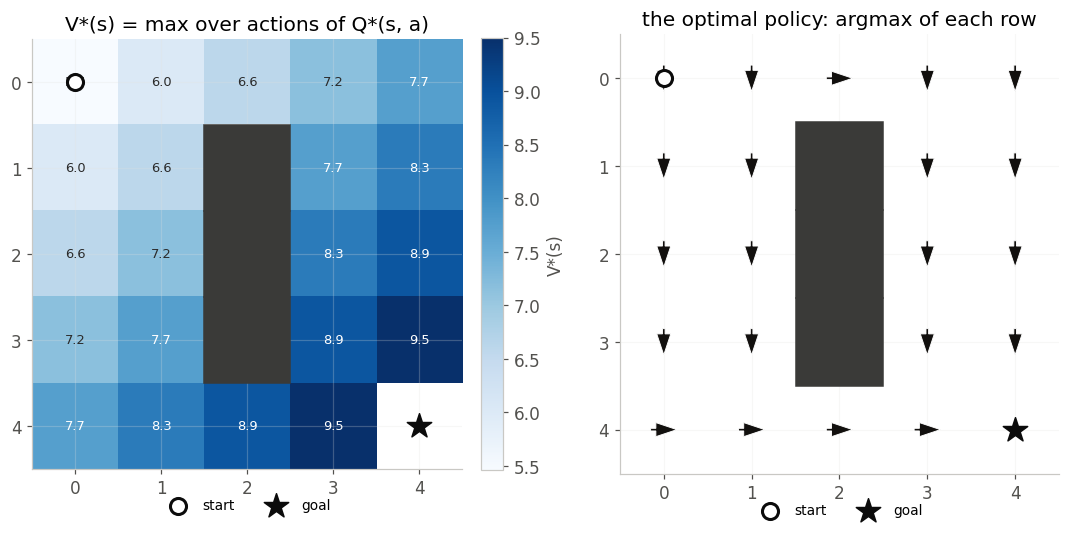

In [5]:
ARROWS = {0: (0.0, -0.3), 1: (0.0, 0.3), 2: (-0.3, 0.0), 3: (0.3, 0.0)}   # (dx, dy) per action

def draw_grid(ax, values=None, policy=None, path=None, path_color=C_DQN, path_label=None,
              annotate=None, fmt="{:.1f}", vmin=None, vmax=None, cmap="Blues", env=BASE):
    size = env.size
    im = None
    # Arrows and numbers in the same cell are unreadable, so the numbers step aside.
    annotate = (values is not None and policy is None) if annotate is None else annotate
    if values is not None:
        # The goal is terminal - it has no value to show, only a star.
        grid = np.full((size, size), np.nan)
        for cell in FREE_CELLS:
            if cell != env.goal:
                grid[cell] = values[cell_index(cell)]
        lo = np.nanmin(grid) if vmin is None else vmin
        hi = np.nanmax(grid) if vmax is None else vmax
        im = ax.imshow(grid, cmap=cmap, vmin=lo, vmax=hi)
        if annotate:
            for cell in FREE_CELLS:
                if np.isnan(grid[cell]):
                    continue
                shade = (grid[cell] - lo) / (hi - lo + 1e-12)
                ax.text(cell[1], cell[0], fmt.format(grid[cell]), ha="center", va="center",
                        fontsize=8.5, color="white" if shade > 0.55 else "#2b2b2b", zorder=3)
    if policy is not None:
        for cell in FREE_CELLS:
            if cell == env.goal:
                continue
            dx, dy = ARROWS[int(policy[cell_index(cell)])]
            ax.arrow(cell[1] - dx / 2, cell[0] - dy / 2, dx, dy, width=0.03, head_width=0.16,
                     length_includes_head=True, facecolor="#12100e", edgecolor="white",
                     linewidth=0.6, zorder=6)
    for (r, c) in env.walls:
        ax.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1, color=C_WALL, zorder=2))
    if path is not None:
        ax.plot([p[1] for p in path], [p[0] for p in path], color=path_color, lw=2.2,
                marker="o", ms=4, label=path_label, zorder=4, alpha=0.85)
    ax.scatter([env.start[1]], [env.start[0]], marker="o", s=110, facecolors="white",
               edgecolors=C_TRUTH, linewidths=2, zorder=7, label="start")
    ax.scatter([env.goal[1]], [env.goal[0]], marker="*", s=280, color=C_TRUTH, zorder=7, label="goal")
    ax.set_xlim(-0.5, size - 0.5); ax.set_ylim(size - 0.5, -0.5)
    ax.set_xticks(range(size)); ax.set_yticks(range(size))
    ax.set_aspect("equal")
    ax.grid(True, color="#e3e2de", linewidth=0.8)
    return im


def greedy_from_q(Q):
    # The policy a Q-table (or a network's outputs) implies: argmax, no exploration.
    return Q.argmax(axis=1)


fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))
im = draw_grid(axes[0], values=V_STAR)
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label="V*(s)")
axes[0].set_title("V*(s) = max over actions of Q*(s, a)")
draw_grid(axes[1], policy=greedy_from_q(Q_STAR))
axes[1].set_title("the optimal policy: argmax of each row")
for ax in axes:
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.04), ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

---
# 2. Tabular Q-learning

Q-learning turns the Bellman equation into an update rule. Keep a table `Q` of
shape `(25, 4)`, act in the world, and after every single transition
`(s, a, r, s')` fill one entry:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \Big[\underbrace{r + \gamma \max_{a'} Q(s',a')}_{\text{TD target}} - Q(s,a)\Big]$$

The bracket is the **temporal-difference error**: the gap between what we
thought this action was worth and what the very next step suggests it is worth.
Three concepts from the lecture.

**It is off-policy.** The target uses `max_a' Q(s', a')`, the value it believes of the
*best* action in the next state, regardless of which action the agent actually
takes next. So the agent can behave badly (explore) while still learning about
good behaviour. 

**It needs exploration.** A greedy agent starting from an all-zero table would always
walk in the same direction. We use **epsilon-greedy**: with probability
`eps` take a random action, otherwise take the greedy one, and anneal `eps` from
1 down to 0.05 so that early episodes explore and later ones exploit.

**`terminated` and `truncated` mean different things here too.** On termination
there *is* no next state, so the target is just `r`. On truncation (the 50-step
budget running out) the episode continues in principle, so we still bootstrap
with `gamma * max Q(s', .)`. This is considered differently because otherwise the agent
would learn that the world ends in 50 steps.

In [7]:
def epsilon_greedy(Q, s, eps, rng_local):
    if rng_local.random() < eps:
        return int(rng_local.integers(N_ACTIONS))
    return int(np.argmax(Q[s]))


REACHABLE = [cell_index(c) for c in FREE_CELLS if c != BASE.goal]

def q_error(Q):
    # Mean |Q - Q*| over the state-action pairs that are actually reachable.
    return float(np.abs(Q[REACHABLE] - Q_STAR[REACHABLE]).mean())


def optimal_action_share(Q):
    # Fraction of states whose greedy action is *an* optimal one. Comparing the
    # chosen action to Q*'s argmax would be unfair: several states have ties.
    chosen = Q[REACHABLE].argmax(axis=1)
    return float(np.mean(Q_STAR[REACHABLE, chosen] > Q_STAR[REACHABLE].max(axis=1) - 1e-6))


def train_tabular(n_episodes=3000, alpha=0.2, gamma=GAMMA, eps_start=1.0, eps_end=0.05,
                  eps_decay_frac=0.5, seed=0, snapshot_at=(1, 10, 100, 3000)):
    rng_local = np.random.default_rng(seed)
    env = make_env()
    Q = np.zeros((N_STATES, N_ACTIONS))

    returns, errors, snapshots = [], [], {}
    total_steps = 0
    for ep in range(1, n_episodes + 1):
        frac = min(1.0, (ep - 1) / (eps_decay_frac * n_episodes))
        eps = eps_start + frac * (eps_end - eps_start)

        obs, _ = env.reset()
        s = state_of(obs)
        ep_return = 0.0
        terminated = truncated = False
        while not (terminated or truncated):
            a = epsilon_greedy(Q, s, eps, rng_local)
            obs2, reward, terminated, truncated, _ = env.step(a)
            s2 = state_of(obs2)

            # bootstrap unless the episode really ended; truncation is not an ending
            target = reward + (0.0 if terminated else gamma * Q[s2].max())
            Q[s, a] += alpha * (target - Q[s, a])

            s = s2
            ep_return += reward
            total_steps += 1

        returns.append((total_steps, ep_return))
        errors.append((total_steps, q_error(Q)))
        if ep in snapshot_at:
            snapshots[ep] = Q.copy()
    return Q, np.array(returns), np.array(errors), snapshots


t0 = time.time()
Q_table, tab_returns, tab_errors, tab_snapshots = train_tabular()
print(f"trained 3000 episodes ({int(tab_returns[-1, 0]):,} environment steps) in {time.time() - t0:.1f}s")
print(f"mean |Q - Q*| after training : {tab_errors[-1, 1]:.3f}")
print(f"states with an optimal greedy action: {optimal_action_share(Q_table):.0%}")

trained 3000 episodes (44,327 environment steps) in 0.3s
mean |Q - Q*| after training : 0.001
states with an optimal greedy action: 100%


## 2.1 Filling the table

An all-zero table knows nothing, and the `+10` at the goal is the only large
number in the whole problem. Q-learning has to carry that number backwards, one
cell per visit, until it reaches the start. Snapshots of `V(s) = max_a Q(s,a)`
after 1, 10, 100 and 3000 episodes show the propagation.

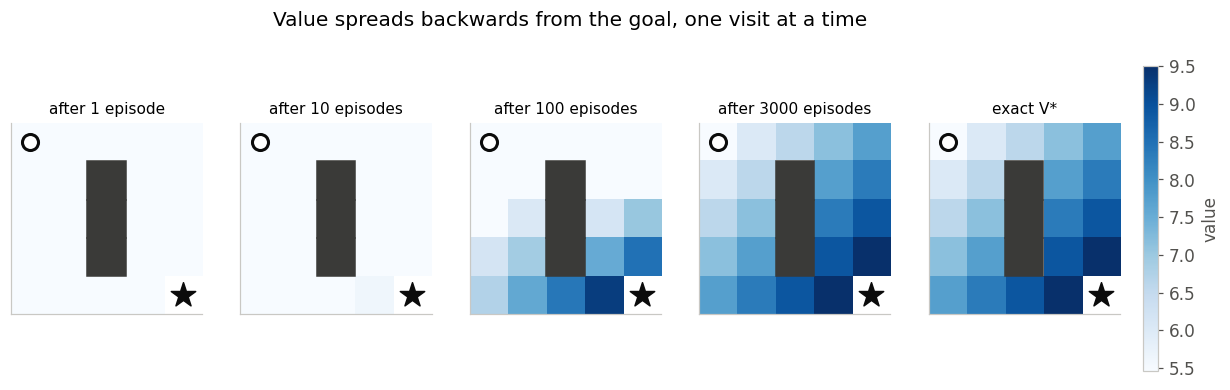

In [8]:
snap_eps = sorted(tab_snapshots)
fig, axes = plt.subplots(1, len(snap_eps) + 1, figsize=(4.2 * (len(snap_eps) + 1) / 1.55, 3.6))
lo, hi = float(V_STAR[REACHABLE].min()), float(V_STAR[REACHABLE].max())
for ax, ep in zip(axes, snap_eps):
    im = draw_grid(ax, values=tab_snapshots[ep].max(axis=1), vmin=lo, vmax=hi, annotate=False)
    ax.set_title(f"after {ep} episode{'s' if ep > 1 else ''}", fontsize=10)
im = draw_grid(axes[-1], values=V_STAR, vmin=lo, vmax=hi, annotate=False)
axes[-1].set_title("exact V*", fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="value")
fig.suptitle("Value spreads backwards from the goal, one visit at a time", y=1.02)
plt.show()

---
# 3. What the table learned

Does the agent *behave* well?
Are its *numbers* right? A policy can be optimal while the values behind it are
still visibly wrong, because the greedy action only depends on which entry in a
row is largest, not on how large it is. On a 25-state grid with enough visits we
should expect both to come out right. In bigger problems this might not be the case.

tabular Q-learning, greedy rollout: 8 steps, return 6.00 (optimal: 8 steps, 6.00)


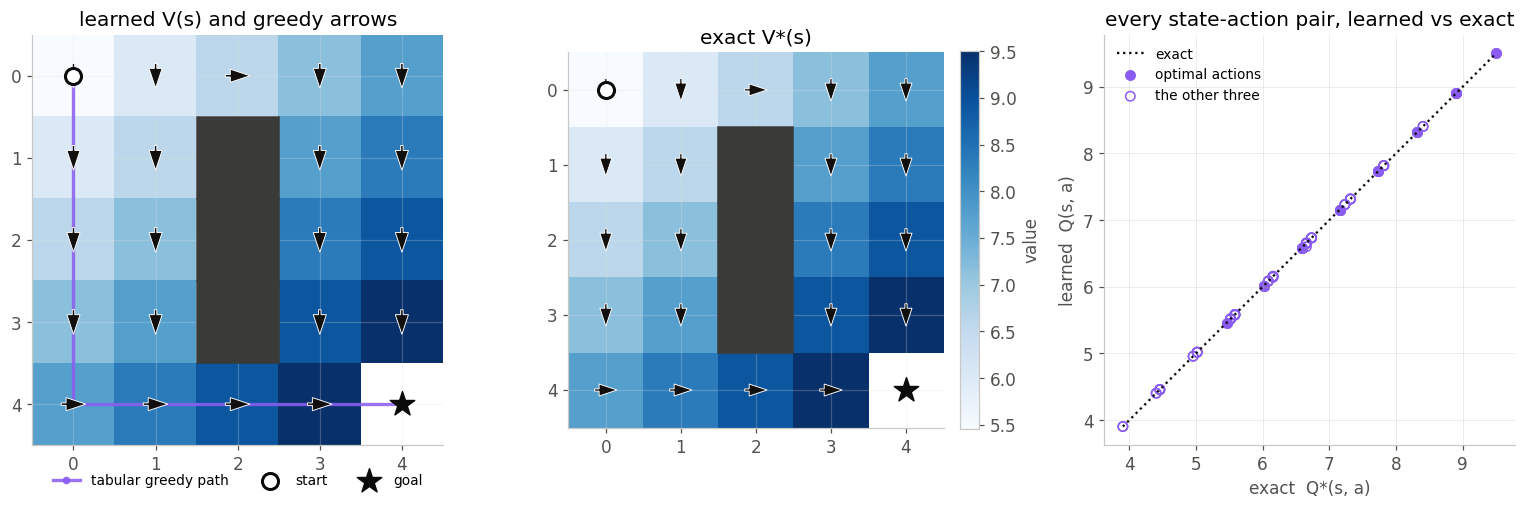

In [10]:
def q_policy(Q):
    return lambda obs: int(np.argmax(Q[state_of(obs)]))


table_path, table_return, table_length = run_episode(q_policy(Q_table))
print(f"tabular Q-learning, greedy rollout: {table_length} steps, return {table_return:.2f} "
      f"(optimal: {OPTIMAL_STEPS} steps, {OPTIMAL_RETURN:.2f})")

V_table = Q_table.max(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
im = draw_grid(axes[0], values=V_table, policy=greedy_from_q(Q_table), path=table_path,
               path_color=C_TABLE, path_label="tabular greedy path", vmin=lo, vmax=hi)
axes[0].set_title("learned V(s) and greedy arrows")
im2 = draw_grid(axes[1], values=V_STAR, policy=greedy_from_q(Q_STAR), vmin=lo, vmax=hi)
axes[1].set_title("exact V*(s)")
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label="value")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.04), ncol=3, fontsize=9)

# All 96 reachable state-action pairs, not just the best one per state: the
# policy only needs the ranking within a row, the values have to be right entry
# by entry, and the scatter shows both at once.
q_true = Q_STAR[REACHABLE]
best_mask = q_true >= q_true.max(axis=1, keepdims=True) - 1e-6
span = [q_true.min(), q_true.max()]
axes[2].plot(span, span, color=C_TRUTH, ls=":", lw=1.5, label="exact")
axes[2].scatter(q_true[best_mask], Q_table[REACHABLE][best_mask], color=C_TABLE, s=38,
                label="optimal actions")
axes[2].scatter(q_true[~best_mask], Q_table[REACHABLE][~best_mask], facecolors="none",
                edgecolors=C_TABLE, s=38, label="the other three")
axes[2].set(xlabel="exact  Q*(s, a)", ylabel="learned  Q(s, a)",
            title="every state-action pair, learned vs exact")
axes[2].set_aspect("equal"); axes[2].legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

## 3.1 The learning curve

These two panels:
episode **return** (did it behave well, undiscounted) and mean **|Q - Q\*|** (are its numbers right, discounted).

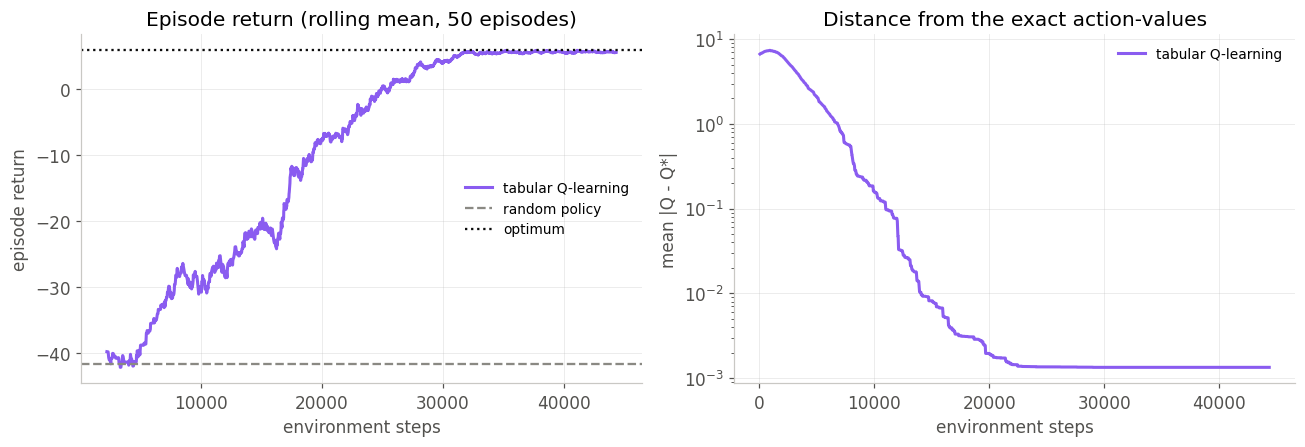

final 50-episode mean return (still exploring): 5.62
greedy rollout return                        : 6.00
mean |Q - Q*| on optimal actions              : 0.000074
mean |Q - Q*| on the three actions it avoids  : 0.002037


In [11]:
def rolling(x, window=50):
    return np.convolve(x, np.ones(window) / window, mode="valid")


WIN = 50
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(tab_returns[WIN - 1:, 0], rolling(tab_returns[:, 1], WIN), color=C_TABLE,
             label="tabular Q-learning")
axes[0].axhline(random_returns.mean(), color=C_RANDOM, ls="--", lw=1.5, label="random policy")
axes[0].axhline(OPTIMAL_RETURN, color=C_TRUTH, ls=":", lw=1.5, label="optimum")
axes[0].set(xlabel="environment steps", ylabel="episode return",
            title=f"Episode return (rolling mean, {WIN} episodes)")
axes[0].legend(loc="center right", fontsize=9)

axes[1].plot(tab_errors[:, 0], tab_errors[:, 1], color=C_TABLE, label="tabular Q-learning")
axes[1].set_yscale("log")
axes[1].set(xlabel="environment steps", ylabel="mean |Q - Q*|",
            title="Distance from the exact action-values")
axes[1].legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

best_actions = Q_STAR[REACHABLE] >= Q_STAR[REACHABLE].max(axis=1, keepdims=True) - 1e-6
tab_err = np.abs(Q_table[REACHABLE] - Q_STAR[REACHABLE])
print(f"final 50-episode mean return (still exploring): {tab_returns[-50:, 1].mean():.2f}")
print(f"greedy rollout return                        : {table_return:.2f}")
print(f"mean |Q - Q*| on optimal actions              : {tab_err[best_actions].mean():.6f}")
print(f"mean |Q - Q*| on the three actions it avoids  : {tab_err[~best_actions].mean():.6f}")

**The return curve plateaus just below the optimum, but the greedy rollout above
hit it exactly.** Remember that the curve measures the *behaviour* policy,
which is still epsilon-greedy with `eps = 0.05`, so one action in twenty is
thrown away at random. What we deploy is the greedy policy, and that one is
worth the full `6.00`.

**The value error falls by nearly four orders of magnitude and then stops dead**,
almost exactly when `eps` reaches its floor. The entries the greedy policy *uses* are off by less than
`1e-4`, and essentially all of what is left sits in the other three actions per state, which a  nearly-greedy agent stopped taking, and therefore stopped learning
about. This means that **a value estimate is only as good as the visits
behind it.** Keep exploring for longer (a slower `eps` schedule) and the error
keeps falling even down to `1e-14` if you let it.

---
# 4. Why the table does not scale

Everything above depended on one line: `Q[s, a]`, with `s` an integer. That
requires the states to be countable, few, and *visitable*, since the table learns
nothing about a state until the agent has experienced it, and it never generalises
between states, because entries are independent numbers.

| Problem | States | A table needs |
|---|---|---|
| this grid | 25 | 100 numbers |
| 100x100 grid | 10,000 | 40,000 numbers, and every cell visited many times |
| Atari (84x84 greyscale frames) | 256^7056 | more entries than atoms in the universe |
| anything continuous (positions, velocities, a flow field) | infinite | impossible |

We can now bring in NN to solve this issue: replace the lookup table with a
**function approximator**, `Q(s, a; theta)`, a network that maps a state to all
four action-values at once. There are two nice things about this: the parameter count stops growing
with the state space, and similar states can produce similar outputs, which generalises the table can. 

---
# 5. DQN: the same update, with a network

The update rule does not change. What changes is that we can no longer *assign*
`Q[s, a]` and we can only take a gradient step that moves the network's output
toward the target. So the assignment becomes a regression loss on the TD error:

$$\mathcal{L}(\theta) = \Big( \underbrace{r + \gamma \max_{a'} Q(s', a'; \theta^-)}_{\text{target, held fixed}} - Q(s,a;\theta) \Big)^2$$

Doing only that is unstable, and on problems of any real size it fails out of the box. There were
Two ingredients from the 2015 DQN paper that made it work, and both address
problems the table doesn't have:

* **A replay buffer.** Consecutive transitions in an episode are strongly
  correlated, and gradient descent assumes roughly independent batches. We store
  transitions in a large buffer and train on *random* minibatches drawn
  from it, which decorrelates the data and reuses each transition many times.
* **A target network.** The regression target contains the network's own
  output, so updating `theta` moves the target we are chasing. We keep a frozen copy `theta-`, use it to compute
  targets, and refresh it every few hundred steps.

Part 6 removes each of them and shows how DQN stops working.

In [12]:
class QNetwork(nn.Module):
    # State in, one value per action out. Note there is no policy head anywhere:
    # the policy is argmax over these four numbers.
    def __init__(self, n_obs=N_STATES, n_actions=N_ACTIONS, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_obs, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity, obs_dim=N_STATES):
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros(capacity, dtype=np.int64)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.terminated = np.zeros(capacity, dtype=np.float32)
        self.capacity, self.size, self.ptr = capacity, 0, 0

    def add(self, obs, action, reward, next_obs, terminated):
        i = self.ptr
        self.obs[i], self.actions[i], self.rewards[i] = obs, action, reward
        self.next_obs[i], self.terminated[i] = next_obs, float(terminated)
        self.ptr = (self.ptr + 1) % self.capacity          # FIFO: overwrite the oldest
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size, rng_local):
        idx = rng_local.integers(0, self.size, size=batch_size)
        return self._as_tensors(idx)

    def latest(self, n=1):
        # Used only for the "no replay buffer" ablation: the n most recent transitions.
        idx = (self.ptr - 1 - np.arange(n)) % self.capacity
        return self._as_tensors(idx)

    def _as_tensors(self, idx):
        return (torch.from_numpy(self.obs[idx]), torch.from_numpy(self.actions[idx]),
                torch.from_numpy(self.rewards[idx]), torch.from_numpy(self.next_obs[idx]),
                torch.from_numpy(self.terminated[idx]))


print(QNetwork())
print(f"\nparameters: {sum(p.numel() for p in QNetwork().parameters()):,} "
      f"(the table had {N_STATES * N_ACTIONS})")

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)

parameters: 6,084 (the table had 100)


## 5.1 The training loop

One pass through it: act epsilon-greedily using the online network, store the
transition, and every couple of steps fit the network to a replayed minibatch.
The `use_replay` and `use_target` flags exist so Part 6 can turn each ingredient
off without a second implementation.

In [13]:
def q_values_of(q_net):
    # The network's whole Q-table, for comparison with Q*: feed it all 25 one-hot states.
    with torch.no_grad():
        return q_net(torch.eye(N_STATES)).numpy()


def train_dqn(total_steps=20_000, lr=1e-3, gamma=GAMMA, batch_size=64, buffer_size=10_000,
              learning_starts=500, train_every=2, target_sync=250, eps_start=1.0, eps_end=0.05,
              eps_decay_frac=0.4, use_replay=True, use_target=True, seed=0, eval_every=500):
    torch.manual_seed(seed)
    rng_local = np.random.default_rng(seed)
    env = make_env()

    q_net = QNetwork()
    target_net = QNetwork()
    target_net.load_state_dict(q_net.state_dict())
    optimizer = torch.optim.Adam(q_net.parameters(), lr=lr)
    buffer = ReplayBuffer(buffer_size)

    returns, errors, losses = [], [], []
    obs, _ = env.reset()
    ep_return = 0.0

    for step in range(1, total_steps + 1):
        frac = min(1.0, step / (eps_decay_frac * total_steps))
        eps = eps_start + frac * (eps_end - eps_start)

        # ---- 1. act ----
        if rng_local.random() < eps:
            action = int(rng_local.integers(N_ACTIONS))
        else:
            with torch.no_grad():
                action = int(q_net(torch.from_numpy(obs)).argmax())

        next_obs, reward, terminated, truncated, _ = env.step(action)
        ep_return += reward
        # `terminated` only: a truncated episode has a real next state to bootstrap from
        buffer.add(obs, action, reward, next_obs, terminated)
        obs = next_obs
        if terminated or truncated:
            returns.append((step, ep_return))
            obs, _ = env.reset()
            ep_return = 0.0

        # ---- 2. learn ----
        if step > learning_starts and step % train_every == 0:
            if use_replay:
                b_obs, b_act, b_rew, b_next, b_term = buffer.sample(batch_size, rng_local)
            else:
                b_obs, b_act, b_rew, b_next, b_term = buffer.latest(1)   # only what just happened

            with torch.no_grad():
                bootstrap_net = target_net if use_target else q_net
                td_target = b_rew + gamma * bootstrap_net(b_next).max(dim=1).values * (1 - b_term)
            predicted = q_net(b_obs).gather(1, b_act.unsqueeze(1)).squeeze(1)
            loss = F.mse_loss(predicted, td_target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append((step, loss.item()))

            if use_target and step % target_sync == 0:
                target_net.load_state_dict(q_net.state_dict())   # refresh the frozen copy

        if step % eval_every == 0:
            errors.append((step, q_error(q_values_of(q_net))))

    return q_net, np.array(returns), np.array(errors), np.array(losses)

In [14]:
t0 = time.time()
q_net, dqn_returns, dqn_errors, dqn_losses = train_dqn()
print(f"DQN: 20,000 environment steps in {time.time() - t0:.1f}s")

Q_dqn = q_values_of(q_net)
dqn_path, dqn_return, dqn_length = run_episode(q_policy(Q_dqn))
print(f"greedy rollout : {dqn_length} steps, return {dqn_return:.2f}")
print(f"mean |Q - Q*|  : {q_error(Q_dqn):.3f}   (tabular: {q_error(Q_table):.3f})")
print(f"states with an optimal greedy action: {optimal_action_share(Q_dqn):.0%}"
      f"   (tabular: {optimal_action_share(Q_table):.0%})")

DQN: 20,000 environment steps in 5.9s
greedy rollout : 8 steps, return 6.00
mean |Q - Q*|  : 0.010   (tabular: 0.001)
states with an optimal greedy action: 100%   (tabular: 100%)


## 5.2 Table and network comparison

Both learners solved the same problem, and both end at the optimal policy. The
network gets there in far fewer environment steps here, but the comparison is subtle because **this is not a controlled comparison of sample efficiency.** The
two runs anneal `eps` on different schedules (over roughly 8,000 steps for DQN,
over roughly 22,000 for the table), and exploration is what paces learning on
this problem. Matching the two schedules is a something we could do, but what we want to show is the *shape* of each curve, and where each one
finally lands.

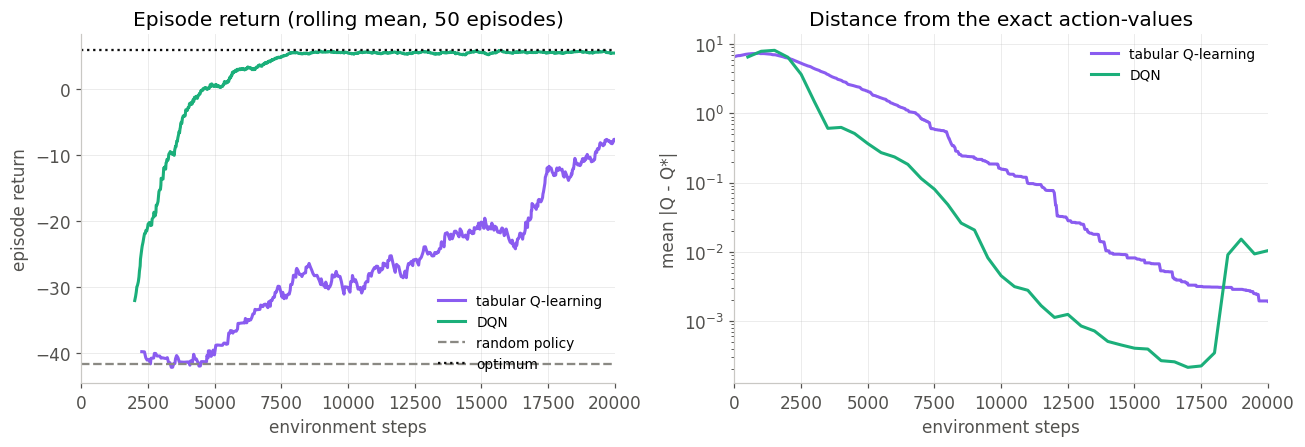

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(tab_returns[WIN - 1:, 0], rolling(tab_returns[:, 1], WIN), color=C_TABLE,
             label="tabular Q-learning")
axes[0].plot(dqn_returns[WIN - 1:, 0], rolling(dqn_returns[:, 1], WIN), color=C_DQN, label="DQN")
axes[0].axhline(random_returns.mean(), color=C_RANDOM, ls="--", lw=1.5, label="random policy")
axes[0].axhline(OPTIMAL_RETURN, color=C_TRUTH, ls=":", lw=1.5, label="optimum")
axes[0].set(xlabel="environment steps", ylabel="episode return", xlim=(0, 20_000),
            title=f"Episode return (rolling mean, {WIN} episodes)")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].plot(tab_errors[:, 0], tab_errors[:, 1], color=C_TABLE, label="tabular Q-learning")
axes[1].plot(dqn_errors[:, 0], dqn_errors[:, 1], color=C_DQN, label="DQN")
axes[1].set_yscale("log")
axes[1].set(xlabel="environment steps", ylabel="mean |Q - Q*|", xlim=(0, 20_000),
            title="Distance from the exact action-values")
axes[1].legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

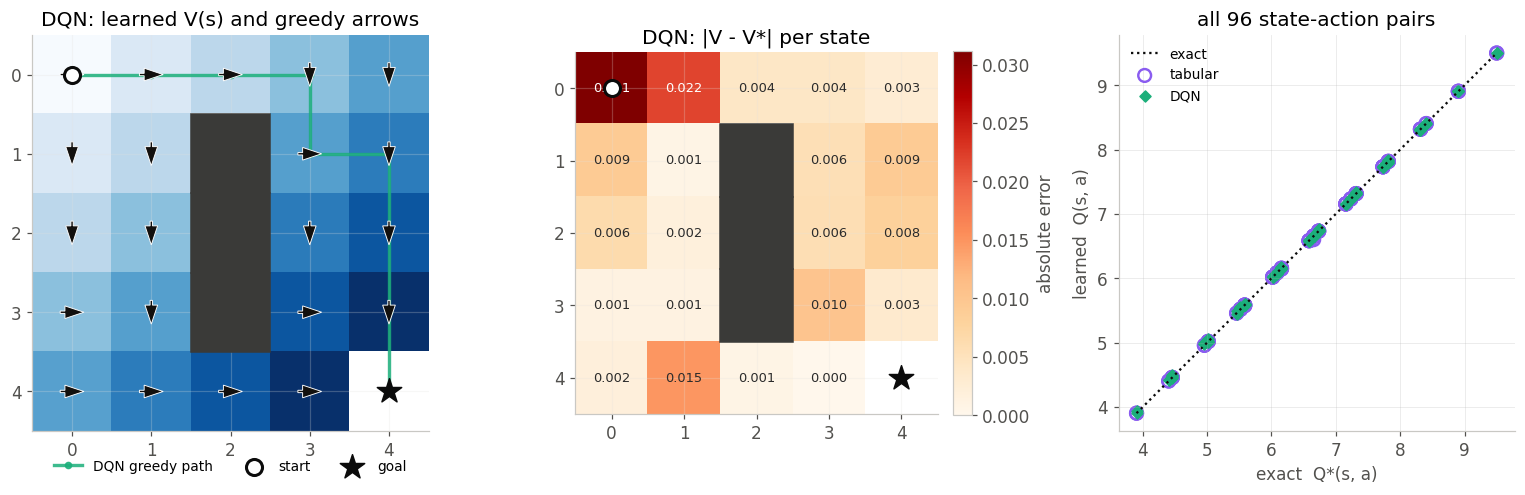

In [17]:
V_dqn = Q_dqn.max(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
im = draw_grid(axes[0], values=V_dqn, policy=greedy_from_q(Q_dqn), path=dqn_path,
               path_color=C_DQN, path_label="DQN greedy path", vmin=lo, vmax=hi)
axes[0].set_title("DQN: learned V(s) and greedy arrows")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.04), ncol=3, fontsize=9)

err_dqn = np.abs(V_dqn - V_STAR)
im2 = draw_grid(axes[1], values=err_dqn, cmap="OrRd", fmt="{:.3f}", vmin=0.0,
                vmax=max(err_dqn[REACHABLE].max(), 1e-6))
axes[1].set_title("DQN: |V - V*| per state")
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label="absolute error")

axes[2].plot(span, span, color=C_TRUTH, ls=":", lw=1.5, label="exact")
axes[2].scatter(q_true.ravel(), Q_table[REACHABLE].ravel(), facecolors="none",
                edgecolors=C_TABLE, s=70, linewidths=1.6, label="tabular")
axes[2].scatter(q_true.ravel(), Q_dqn[REACHABLE].ravel(), color=C_DQN, s=26, marker="D",
                label="DQN")
axes[2].set(xlabel="exact  Q*(s, a)", ylabel="learned  Q(s, a)",
            title="all 96 state-action pairs")
axes[2].set_aspect("equal"); axes[2].legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

Both learners end up at the same policy and nearly the same numbers, and the
DQN's residual error is a few times the table's. That is the expected result,
and it is worth understanding *why* the network wins nothing here.

Our observation is **one-hot**. Every state is orthogonal to every other, so the
network has no structure to exploit: it is doing an expensive impression of a
lookup table, with 6,084 parameters standing in for 100 numbers, and the price
is a slightly looser fit. Generalisation is not something a network provides
automatically. It comes from the *input representation*. Feed it the agent's
`(row, col)` as two floats, or a local view of the grid, and neighbouring states
share features, gradients from one state genuinely inform its neighbours, and
the network starts doing something the table cannot. That experiment is the last
exercise at the end of this notebook.

What the network still gets us is feasibility

---
# 6. How much do replay and the target network matter?

Part 5 claimed both ingredients are load-bearing. That is a cheap claim to
test — the flags are already in `train_dqn` — so we retrain with each one
removed, two seeds each, and measure both things that could break: the
behaviour (episode return) and the values (`|Q - Q*|`). Small multiples, one
column per variant, so no curve hides behind another.

In [18]:
ABLATIONS = [
    ("full DQN",            dict(use_replay=True,  use_target=True),  C_DQN),
    ("no target network",   dict(use_replay=True,  use_target=False), C_NOTGT),
    ("no replay buffer",    dict(use_replay=False, use_target=True),  C_NOBUF),
]
SEEDS = (0, 1)

t0 = time.time()
ablation_runs = {}
for name, flags, _ in ABLATIONS:
    for seed in SEEDS:
        _, rets, errs, _ = train_dqn(total_steps=12_000, seed=seed, eval_every=500, **flags)
        ablation_runs[(name, seed)] = (rets, errs)
    print(f"{name:<18} done")
print(f"\n{len(ABLATIONS) * len(SEEDS)} runs in {time.time() - t0:.1f}s")

full DQN           done
no target network  done
no replay buffer   done

6 runs in 17.2s


In [1]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.0), sharex=True, sharey="row")
for col, (name, _, colour) in enumerate(ABLATIONS):
    top, bottom = axes[0, col], axes[1, col]
    for i, seed in enumerate(SEEDS):
        rets, errs = ablation_runs[(name, seed)]
        top.plot(rets[WIN - 1:, 0], rolling(rets[:, 1], WIN), color=colour,
                 alpha=1.0 if i == 0 else 0.45, label=f"seed {seed}")
        bottom.plot(errs[:, 0], errs[:, 1], color=colour, alpha=1.0 if i == 0 else 0.45)
    top.axhline(random_returns.mean(), color=C_RANDOM, ls="--", lw=1.3, label="random policy")
    top.axhline(OPTIMAL_RETURN, color=C_TRUTH, ls=":", lw=1.3, label="optimum")
    top.set_title(name)
    top.legend(loc="center right", fontsize=8)
    bottom.set(xlabel="environment steps", yscale="log")
axes[0, 0].set_ylabel(f"episode return\n(rolling mean, {WIN} episodes)")
axes[1, 0].set_ylabel("mean |Q - Q*|")
fig.suptitle("The policy is still good on a 25-state grid the value estimates get worse", y=0.98)
plt.tight_layout(); plt.show()

print(f"{'variant':<20}{'final return':>14}{'mean |Q - Q*|':>16}")
for name, _, _ in ABLATIONS:
    finals = [ablation_runs[(name, s)][0][-50:, 1].mean() for s in SEEDS]
    errs = [ablation_runs[(name, s)][1][-1, 1] for s in SEEDS]
    print(f"{name:<20}{np.mean(finals):>14.2f}{np.mean(errs):>16.3f}")

NameError: name 'plt' is not defined

All three variants
still reach the goal: on a 25-state grid with a dense shaping reward, the policy
is easy enough that a damaged learner recovers it anyway. The *value* row shows 
roughly two orders of magnitude
of `|Q - Q*|` between the full agent and either ablation, on the exact same
number of environment steps.

**Without the target network** the regression chases its own output. Each
gradient step changes the prediction *and* the target that prediction is fit to,
so errors feed back on themselves instead of being corrected. In the bottom
row that is the sawtooth: the error repeatedly falls and then jumps back up,
and never gets below roughly `0.3`.

**Without the replay buffer** the network trains on one fresh transition at a
time. Consecutive transitions come from the same corner of the grid, so every
update is a highly correlated sample: the network fits wherever the agent
currently is and drifts everywhere else, over and over. Its value error simply
flattens out around `1` and stops improving. It is the RL version of training a
classifier by showing it all the cats first and then all the dogs.

Both pathologies get worse with the size of the state space and the sparsity of
the reward, which is why the original DQN paper's Atari ablations are more dramatic.
And note that the *tabular* agent needed neither ingredient: both problems are created by function approximation, since
updating a shared parameter vector changes `Q` everywhere at once, whereas
`Q[s, a] += ...` touches one number and cannot interfere with anything
else.
